In [ ]:
from langchain_ollama.chat_models import ChatOllama

model = ChatOllama(
    model="llama3:8b",
    base_url="http://localhost:11434",
    format="json",
)


SyntaxError: invalid syntax. Perhaps you forgot a comma? (370208169.py, line 4)

In [74]:
llm.invoke("Who are you?")

AIMessage(content='I am Gemma, an open-weights AI assistant. I am a large language model trained by Google DeepMind.', additional_kwargs={}, response_metadata={'model': 'gemma3:270m', 'created_at': '2025-12-07T08:03:33.502321278Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3003083116, 'load_duration': 2405885552, 'prompt_eval_count': 13, 'prompt_eval_duration': 30707269, 'eval_count': 24, 'eval_duration': 511329574, 'logprobs': None, 'model_name': 'gemma3:270m', 'model_provider': 'ollama'}, id='lc_run--019af7d6-5640-7630-b705-efc642387992-0', usage_metadata={'input_tokens': 13, 'output_tokens': 24, 'total_tokens': 37})

In [75]:
from typing import Annotated
from typing_extensions import TypedDict 
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[str], add_messages]

In [76]:
from langgraph.graph import StateGraph

grapg_builder = StateGraph(State)

In [77]:
from langchain_core.tools import tool
from datetime import datetime
import pytz
from zoneinfo import ZoneInfo

@tool
def get_current_time(timezone: str, location: str) -> str:
    """현재 시각을 반환하는 함수"""

    try:
        target_timezone = ZoneInfo(timezone)
        now = datetime.now(target_timezone)
        location_and_local_time = f'{timezone} ({location}) 현재시각 {now}'
        return location_and_local_time
    except pytz.UnknownTimeZoneError:
        return f"알 수 없는 타임존: {timezone}"


In [78]:
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper

@tool
def get_web_search(query: str, search_period: str='w') -> str:
    """
    웹 검색을 수행하는 함수.

    Args:
        query (str): 검색어
        search_period (str): 검색 기간 (e.g., "w" for past week (default), "m" for past month, "y" for past year, "d" for past day)

    Returns:
        str: 검색 결과
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        region="kr-kr",
        time=search_period
    )

    print('\n----- WEB SEARCH -----')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        source="news",
        results_separator=';\n'
    )

    searched = search.invoke(query)
    
    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')
    
    return searched

In [79]:
tools = [get_current_time, get_web_search]

In [80]:
tools[0].invoke({"timezone": "Asia/Seoul", "location": "부산"})

'Asia/Seoul (부산) 현재시각 2025-12-07 17:03:33.578535+09:00'

In [81]:
tools[1].invoke({"query": "2025년 쿠팡 개인정보 유출 사건의 원인은?"})


----- WEB SEARCH -----
2025년 쿠팡 개인정보 유출 사건의 원인은?
w
1. snippet: 6 days ago - 관리적 실패: 퇴사한 중국인 직원(인증 담당)이 방치된 액세스 토큰 서명키를 악용해 접근 함에 따라, 「정보보호조치에 관한 지침」 및 「표준 개인정보 보호지침」상 퇴직 시 접근 권한 즉시 제거 의무 위반 확인., title: 쿠팡 3,370만 명 개인정보 유출 사태: 팩트체크 및 ..., link: https://lawpid.kr/쿠팡-3370만-명-개인정보-유출-사태-팩트체크-및-관련-보/
2. snippet: 1 week ago - 쿠팡이 유출자에 대하여 서울경찰청 사이버수사대로 고소함. 유출자는 특정되지 않음. 언론은 쿠팡에서 퇴사하여 한국을 떠난 중국 국적자의 전직 직원으로 추정된다고 보도함 · o 2025. 11. 29. 쿠팡의 개인정보 노출 통지, title: 쿠팡 개인정보 3,370만개 유출 사건 정리 (2025년) | ..., link: https://www.nepla.ai/wiki/it-정보-방송통신/개인정보-위치정보-신용정보/쿠팡-개인정보-3-370만개-유출-사건-정리-2025년-w5dnz3w648e6
3. snippet: 5 days ago - “피의자는 개발자… 훔친 서명키 사용 ”, 쿠팡의 퇴사한 직원이 이용자 3370만명의 개인정보를 유출한 사태와 관련, 유출된 개인정보에 이용자들의 공동현관 비밀번호도 일부 포함된 ..., title: 쿠팡 개인정보 유출, ‘공동현관 비밀번호’도 털렸다 | 서울신문, link: https://www.seoul.co.kr/news/politics/congress/2025/12/02/20251202500128
4. snippet: 2 days ago - Q.지금 알리는 이유가 무엇인가요. A.2025년 11월 18일, 쿠팡은 약 4,500명의 고객 계정과 관련된 개인정보 무단 접근 사실을 인지했습니다. 후속 조사 결과 3370만건의 계정 정보가 노출 되었다는 것을 알게 

'snippet: 6 days ago - 관리적 실패: 퇴사한 중국인 직원(인증 담당)이 방치된 액세스 토큰 서명키를 악용해 접근 함에 따라, 「정보보호조치에 관한 지침」 및 「표준 개인정보 보호지침」상 퇴직 시 접근 권한 즉시 제거 의무 위반 확인., title: 쿠팡 3,370만 명 개인정보 유출 사태: 팩트체크 및 ..., link: https://lawpid.kr/쿠팡-3370만-명-개인정보-유출-사태-팩트체크-및-관련-보/;\nsnippet: 1 week ago - 쿠팡이 유출자에 대하여 서울경찰청 사이버수사대로 고소함. 유출자는 특정되지 않음. 언론은 쿠팡에서 퇴사하여 한국을 떠난 중국 국적자의 전직 직원으로 추정된다고 보도함 · o 2025. 11. 29. 쿠팡의 개인정보 노출 통지, title: 쿠팡 개인정보 3,370만개 유출 사건 정리 (2025년) | ..., link: https://www.nepla.ai/wiki/it-정보-방송통신/개인정보-위치정보-신용정보/쿠팡-개인정보-3-370만개-유출-사건-정리-2025년-w5dnz3w648e6;\nsnippet: 5 days ago - “피의자는 개발자… 훔친 서명키 사용 ”, 쿠팡의 퇴사한 직원이 이용자 3370만명의 개인정보를 유출한 사태와 관련, 유출된 개인정보에 이용자들의 공동현관 비밀번호도 일부 포함된 ..., title: 쿠팡 개인정보 유출, ‘공동현관 비밀번호’도 털렸다 | 서울신문, link: https://www.seoul.co.kr/news/politics/congress/2025/12/02/20251202500128;\nsnippet: 2 days ago - Q.지금 알리는 이유가 무엇인가요. A.2025년 11월 18일, 쿠팡은 약 4,500명의 고객 계정과 관련된 개인정보 무단 접근 사실을 인지했습니다. 후속 조사 결과 3370만건의 계정 정보가 노출 되었다는 것을 알게 되었습니다., title: 쿠팡 개인정보 유출 사건 총정리: 3,370만 명 정보 털림, 집단소송과 보

In [82]:
llm.bind

<bound method Runnable.bind of ChatOllama(model='gemma3:270m', base_url='http://localhost:11434')>

In [83]:
llm_with_tools = llm.bind_tools(tools)

In [84]:
def generate(state: State):
    return {"add_messages": llm_with_tools.invoke(state["messages"])}

In [85]:
grapg_builder.add_node("generate", generate)

In [86]:
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(tools=tools)

In [87]:
grapg_builder.add_node("tools", tool_node)

In [88]:
from langgraph.graph import START, END

def route_tools(state: State):
    """
    마지막 메세지에 도구 호출이 있는 경우 ToolNode로 라우팅하고
    그렇지 않은 경우 END로 라우팅하기 위해 conditional_edge에섯 사용합니다.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"tool_edge 입력 상태에서 메시지를 찾을 수 없습니다: {state}")
    
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

In [89]:
grapg_builder.add_edge(START, "generate")

grapg_builder.add_conditional_edges(
    "generate",
    route_tools,
    {
        "tools": "tools",
        END: END
    }
)

grapg_builder.add_edge("tools", "generate")

In [90]:
graph = grapg_builder.compile()

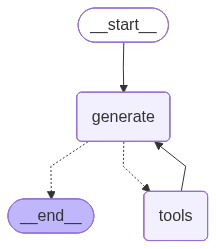

In [91]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))